In [86]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.optim import Adam
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'



Define Neural Network and custom loss function. 
The loss function minimises energy, enforces boundary conditions (bunded wavefunction) and imposes normalization

In [ ]:
#make the neural network and loss function

class Net(nn.Module):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.layers = nn.Sequential(nn.Linear(1,20),
                               nn.ReLU(),
                               nn.Linear(20,20),
                               nn.ReLU(),
                               nn.Linear(20,10),
                               nn.ReLU(),
                               nn.Linear(10,1)
                               )
    def forward(self,x):
        x=self.layers(x)
        return x**2

class cust_loss():
    '''
    This loss will depend on the Hamiltonian.
    Incorporate here as position (or momentum if easier) wavefunction operator
    '''
    def __init__(self,domain,grid_points,f,e_weight=1,bc_weight=1,norm_weight=5):
        '''domain is the min and max of where wavefunction lives
        grid_points is the number of points to use when integrating 
        weights are for the loss funciton
        f is the neural net/ what is used to do the approx of GS'''
        self.domain  = domain
        self.grid_points = grid_points
        self.e_weight = e_weight
        self.bc_weight = bc_weight
        self.norm_weight = norm_weight
        self.f = f
        
    def Ham(self,x):
        '''f must be a (sequence of) torch operators, x a tensor with grad
        '''
        #KINETIC ENERGY
        #(dx)
        p = torch.autograd.grad(self.f(x).sum(),x,create_graph=True)[0]
        #ddx -> kinetic energy
        T = torch.autograd.grad(p.sum(),x,retain_graph=True)[0]
        #POTENTIAL ENERGY
        V = x**2
        return -T + V
    
    def braket(self,f,g):
        '''compute inner product of f and g:
        integrate over domain (f* g dr)
        do this thru simpsons rule'''
        #grid points
        grid = torch.linspace(self.domain[0],self.domain[1],self.grid_points,device=DEVICE,requires_grad=True).unsqueeze(-1)
        grid_eval = (f(grid)*g(grid)).squeeze(-1)
        #weights for simpsons rule: have to be 1,2,4,2,4,2,...1
        weights = torch.arange(0,self.grid_points,dtype=torch.float,device=DEVICE)%2
        weights = weights*2 + 2
        weights[0] = 1
        weights[-1] = 1
        #step size
        h = (self.domain[1]-self.domain[0])/self.grid_points
        #using simpsons composite 1/3 rule
        return torch.dot(grid_eval,weights)*h/3
    
    def get_energy(self):
        ket = self.Ham
        bra = self.f
        energy = self.braket(bra,ket)
        return energy
    def get_norm(self):
        ket = self.f
        bra = self.f
        norm = self.braket(bra,ket)
        return norm
    
    def get_loss(self):

        #energy loss
        ket = self.Ham
        bra = self.f
        energy = self.braket(bra,ket)
        energy_loss = energy**2

        #enforcing boundary conditions:
        #psi ->0 at +- infinity or domain edges
        bc_loss = (self.f(self.domain[0].unsqueeze(-1)) + self.f(self.domain[-1].unsqueeze(-1)))**2

        #normalisation |<psi|psi>|=1 condition, also helps avoid trivial 0 solution
        norm_loss = (self.braket(self.f,self.f)-1)**2

        total_loss = (self.e_weight*energy_loss+self.bc_weight*bc_loss)/(self.norm_weight*norm_loss**2)    
        return total_loss


Training arc. Adam optimiser as preference but no reason behind it

In [84]:
net = Net().to(DEVICE)
for name, p in net.named_parameters():
    print(name, p.device)
for name, b in net.named_buffers():
    print("buffer", name, b.device)
optimiser = Adam(net.parameters())
epochs = 5000
domain = torch.tensor((-10,10),dtype=torch.float,requires_grad=True,device=DEVICE)
loss_fn = cust_loss(domain=domain,grid_points=1000,f=net)
loss_hist = []
energy_hist = []
print('beginning')
for epoch in range(epochs):

    loss = loss_fn.get_loss()
    energy = loss_fn.get_energy()
    loss_hist.append(loss.item())
    energy_hist.append(energy.item())

    loss.backward()
    optimiser.step()
    optimiser.zero_grad()
    if epoch % 5 == 0:
        print(f'epoch : {epoch} loss : {loss} energy : {energy} norm : {loss_fn.get_norm()}')


layers.0.weight cuda:0
layers.0.bias cuda:0
layers.2.weight cuda:0
layers.2.bias cuda:0
layers.4.weight cuda:0
layers.4.bias cuda:0
layers.6.weight cuda:0
layers.6.bias cuda:0
beginning
epoch : 0 loss : tensor([2048.0371], device='cuda:0', grad_fn=<DivBackward0>) energy : 62.34813690185547 norm : 0.18438220024108887
epoch : 5 loss : tensor([418.2395], device='cuda:0', grad_fn=<DivBackward0>) energy : 35.70866394042969 norm : 0.10601969808340073
epoch : 10 loss : tensor([237.7663], device='cuda:0', grad_fn=<DivBackward0>) energy : 29.377119064331055 norm : 0.07189059257507324
epoch : 15 loss : tensor([174.9100], device='cuda:0', grad_fn=<DivBackward0>) energy : 26.328994750976562 norm : 0.053321436047554016
epoch : 20 loss : tensor([109.9040], device='cuda:0', grad_fn=<DivBackward0>) energy : 21.479476928710938 norm : 0.04056804999709129
epoch : 25 loss : tensor([63.5251], device='cuda:0', grad_fn=<DivBackward0>) energy : 16.646684646606445 norm : 0.032160744071006775
epoch : 30 loss : 

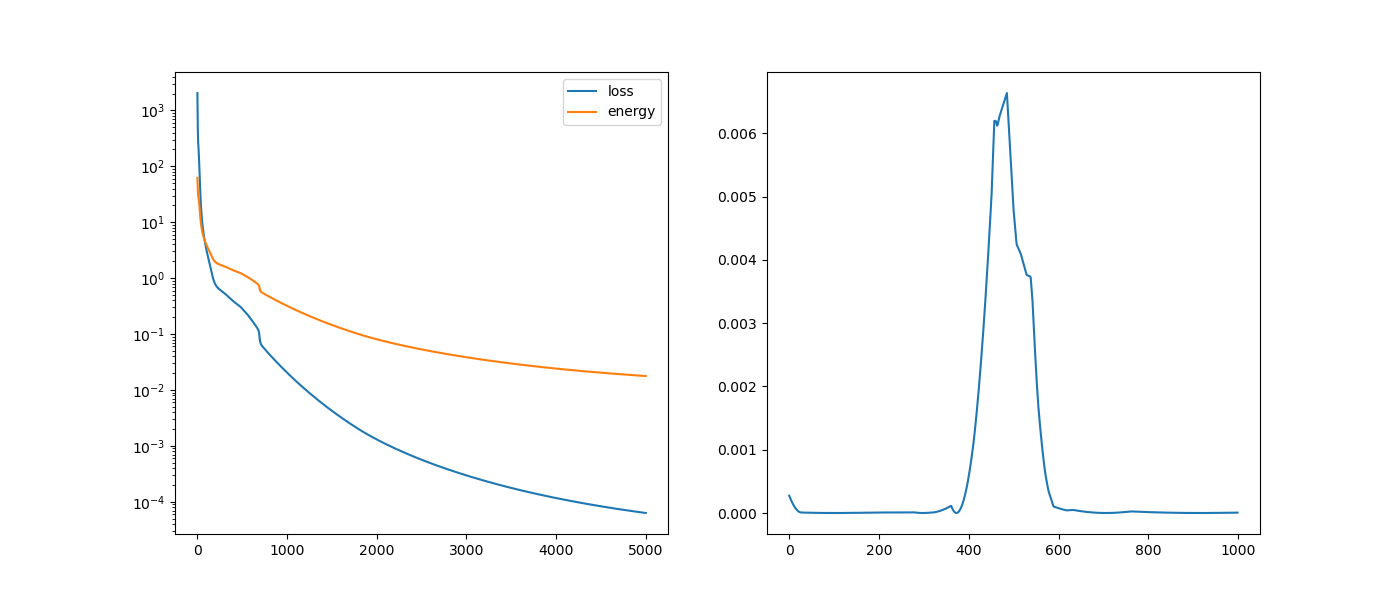

In [85]:
%matplotlib widget
plt.close('all')
domain2 = torch.linspace(domain[0],domain[1],1000,device='cpu',requires_grad=False).unsqueeze(-1)
net.to('cpu')
psi = net(domain2).detach()
fig,(ax1,ax2) = plt.subplots(1,2,figsize=(14,6))
ax1.plot(loss_hist,label='loss')
ax1.plot(energy_hist,label='energy')
ax1.set_yscale('log')
ax2.plot(psi,label='psi')
ax1.legend()
plt.show()

In [ ]:
#checking solution
def tru_psi(x):
    return torch.exp(-x**2/2)/(np.pi**0.25)
net.to(DEVICE)
norm = loss_fn.get_norm()
overlap = loss_fn.braket(net,tru_psi)
print(loss_fn.get_energy()/norm**0.5)
print(overlap/norm**0.5)
#it works!!

tensor(2.3026, device='cuda:0', grad_fn=<DivBackward0>)
tensor(0.9548, device='cuda:0', grad_fn=<DivBackward0>)
